## Handwrite digits

In [2]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [21]:
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
# Prepara i dati (X sono le immagini, y sono le etichette)
X = digits.images.reshape((len(digits.images), -1))  # Appiattisce le immagini 8x8 in vettori 1D (lo vuole isomap)
y = digits.target
n_components = 2
# Scegli il numero di vicini da considerare (parametro importante da regolare)
n_neighbors = 8

print(f"Inizializzazione di Isomap con n_components={n_components} e n_neighbors={n_neighbors}")
isomap = Isomap(n_neighbors=n_neighbors,
                n_components=n_components,
                n_jobs=-1)
X_iso = isomap.fit_transform(X)

X_iso_train, X_iso_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dimensioni del training set: {X_iso_train.shape}")
print(f"Dimensioni del test set: {X_iso_test.shape}")
print(f'Img was {X[0]}, now is {X_iso[0]}')

Inizializzazione di Isomap con n_components=2 e n_neighbors=8
Dimensioni del training set: (1437, 64)
Dimensioni del test set: (360, 64)
Img was [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.], now is [-114.39492485  -19.31411972]


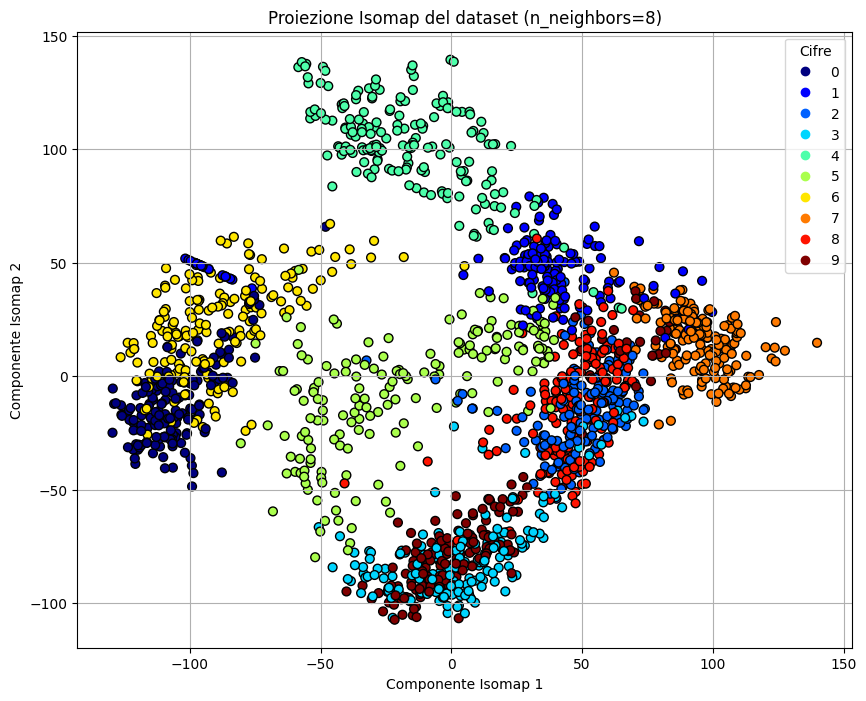

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y, cmap=plt.colormaps["jet"], edgecolor='k', s=40)
plt.title(f'Proiezione Isomap del dataset (n_neighbors={n_neighbors})')
plt.xlabel('Componente Isomap 1')
plt.ylabel('Componente Isomap 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Cifre")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create and train the model
clf = LogisticRegression(solver='sag', max_iter=1000)
clf.fit(X_iso_train, y_train)

# Make predictions
y_pred = clf.predict(X_iso_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")


# Print performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.975
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



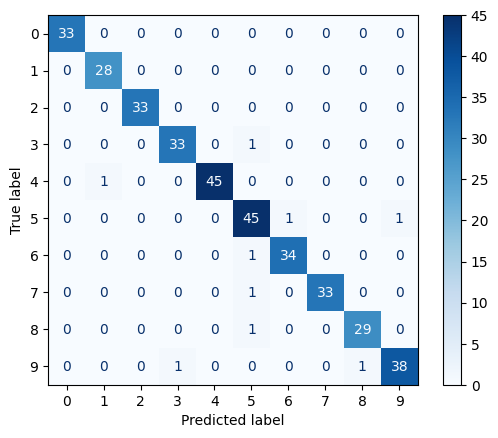

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Genera la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizza la matrice di confusione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap="Blues")